## Bài toán tìm constrast hợp 

In [10]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt

In [11]:

def adjust_gamma(image, gamma):

    invGamma = 1.0 / gamma
    lookup_table = np.array([((i / 255.0) ** invGamma) * 255
                             for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, lookup_table)



def apply_gamma_region(img, gamma, grid_size): 

    height, width = img.shape[:2]
    new_img = img.copy()
    rh, rw = height // grid_size, width // grid_size
    output = np.zeros_like(img)
    
    for i in range(grid_size): 
        for j in range(grid_size): 
            y1, y2 = i * rh, (i+1) * rh
            x1, x2 = j * rw, (j+1) * rw 
            gamma_value = gamma[i][j]
            
    

            output[y1:y2, x1:x2] = adjust_gamma(img[y1:y2, x1:x2], gamma_value)
            
    return output

In [12]:
image = cv2.imread('imgimg.jpg')
# init gamma values 
gamma_values = [[0.5, 1.5], [2.0, 0.8]]

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.show()

KeyboardInterrupt: 

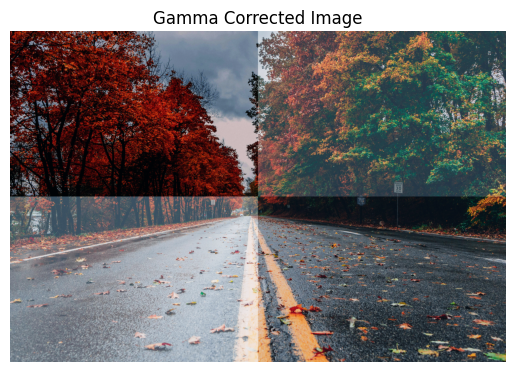

In [ ]:
new_image   = apply_gamma_region(image, gamma_values, 2)

plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))
plt.title('Gamma Corrected Image')
plt.axis('off')
plt.show()

In [ ]:
# # for tưng diem anh

# def smooth(img, grid_size, gamma_value):
#     height, width = img.shape[:2]
#     sh, sw = height // grid_size, width // grid_size


#     new_img = img.copy()

#     for i in range(3): 
#         for j in range(height): 
#             for k in range(width): 
#                 gamma = gamma_value[j//sh][k//sw]
#                 new_image[j][k][i] = 225 * (new_image[j][k][i] / 255) ** (1.0 / gamma) 

#     new_img = np.clip(new_img, 0, 255).astype(np.uint8)


#     return cv2.cvtColor(new_img, cv2.COLOR_BGR2RGB)
                 
                
# new_img = smooth(new_image, 2, gamma_values)
# plt.imshow(new_img)
# plt.title('Smoothed Image')
# plt.axis('off')
# plt.show()

KeyboardInterrupt: 

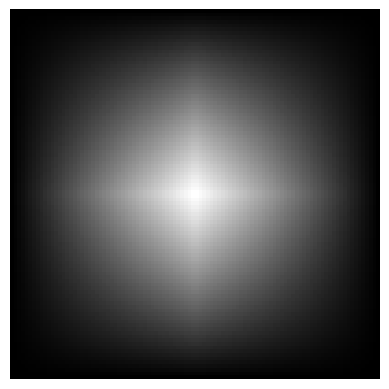

In [ ]:
def create_smooth_mask(h, w, size): 
    mask_x = np.linspace(0, w, size)
    mask_y = np.linspace(0, h, size)

    mask_x = np.concatenate([mask_x, np.ones(w - 2 * size), mask_x[::-1]])
    mask_y = np.concatenate([mask_y, np.ones(h - 2 * size), mask_y[::-1]])
    mask = np.outer(mask_y, mask_x)

    return mask[:, : , None]


temp = create_smooth_mask(100, 100, 50)
plt.imshow(temp, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
def apply_smooth_method(image, grid_size):

    height, width = image.shape[:2]
    rh, rw = height // grid_size, width // grid_size
    output = np.zeros_like(image, dtype = np.float32)
    weight_map = np.zeros_like(image, dtype = np.float32)

    for i in range(grid_size):
        for j in range(grid_size):
            x1, x2 = i * rh, (i+1) * rh
            y1, y2 = j * rw, (j+1) * rw

            mask = create_smooth_mask(y2 - y1, x2 - x1, 30)
            print(image.shape, mask.shape)

            output[y1:y2, x1:x2] += image[y1:y2, x1:x2] * mask
            weight_map[y1:y2, x1:x2] += mask

    return output / weight_map

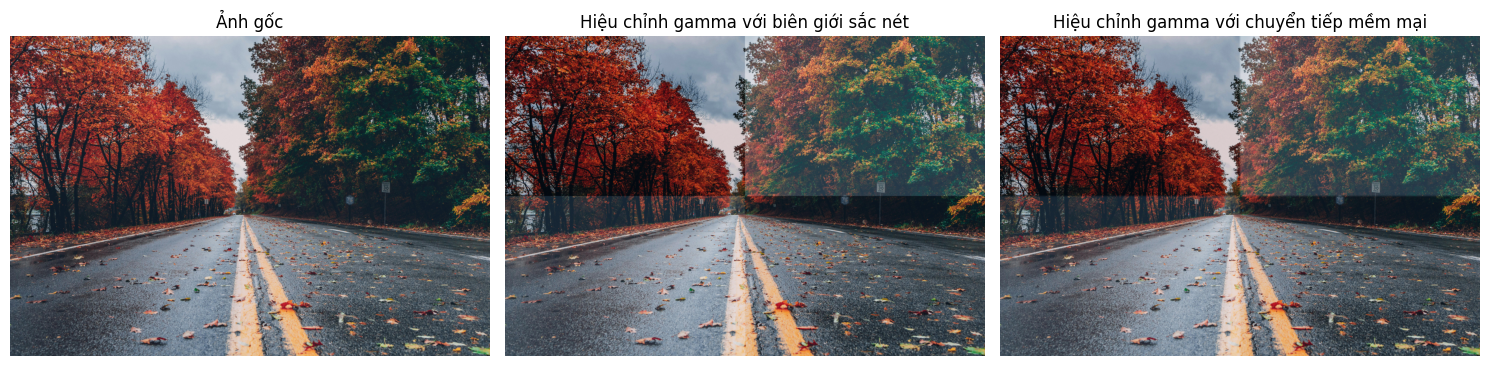

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_gamma_correction(image, gamma):
    """Áp dụng hiệu chỉnh gamma cho ảnh"""
    # Chuẩn hóa ảnh về khoảng [0, 1]
    normalized = image / 255.0
    # Áp dụng công thức gamma: pixel^(1/gamma)
    corrected = np.power(normalized, 1.0 / gamma)
    # Chuyển lại về khoảng [0, 255]
    return (corrected * 255).astype(np.uint8)

def create_blended_gamma_mask(image_shape, regions, blur_size=51):
    """
    Tạo mặt nạ mềm cho việc chuyển tiếp giữa các vùng gamma
    
    Parameters:
    - image_shape: Kích thước của ảnh (height, width)
    - regions: Danh sách các vùng với format [(x1, y1, x2, y2, gamma), ...]
    - blur_size: Kích thước làm mờ biên giữa các vùng (phải là số lẻ)
    
    Returns:
    - Danh sách các mặt nạ mềm tương ứng với từng giá trị gamma
    """
    # Đảm bảo blur_size là số lẻ
    if blur_size % 2 == 0:
        blur_size += 1
    
    height, width = image_shape[:2]
    masks = {}
    
    # Tạo mặt nạ cho từng giá trị gamma
    for region in regions:
        x1, y1, x2, y2, gamma = region
        
        if gamma not in masks:
            masks[gamma] = np.zeros((height, width), dtype=np.float32)
            
        # Tạo mặt nạ nhị phân cho vùng hiện tại
        mask = np.zeros((height, width), dtype=np.float32)
        mask[y1:y2, x1:x2] = 1.0
        
        # Làm mờ mặt nạ để tạo chuyển tiếp mềm mại
        mask = cv2.GaussianBlur(mask, (blur_size, blur_size), 0)
        
        # Cộng dồn vào mặt nạ cho gamma tương ứng
        masks[gamma] += mask
    
    # Chuẩn hóa các mặt nạ để tổng tại mỗi pixel bằng 1
    total_mask = np.zeros((height, width), dtype=np.float32)
    for gamma in masks:
        total_mask += masks[gamma]
    
    for gamma in masks:
        masks[gamma] = np.divide(masks[gamma], total_mask, out=np.zeros_like(masks[gamma]), where=total_mask!=0)
    
    return masks

def blend_gamma_corrections(image, regions, blur_size=51):
    """
    Áp dụng hiệu chỉnh gamma với các chuyển tiếp mềm mại
    
    Parameters:
    - image: Ảnh đầu vào
    - regions: Danh sách các vùng với format [(x1, y1, x2, y2, gamma), ...]
    - blur_size: Kích thước làm mờ biên giữa các vùng (phải là số lẻ)
    
    Returns:
    - Ảnh đã được hiệu chỉnh gamma với các chuyển tiếp mềm mại
    """
    # Đảm bảo blur_size là số lẻ
    if blur_size % 2 == 0:
        blur_size += 1
    
    # Tạo các mặt nạ mềm
    masks = create_blended_gamma_mask(image.shape, regions, blur_size)
    
    # Ảnh kết quả
    result = np.zeros_like(image, dtype=np.float32)
    
    # Áp dụng hiệu chỉnh gamma cho từng vùng và kết hợp lại
    for gamma, mask in masks.items():
        # Áp dụng hiệu chỉnh gamma
        gamma_corrected = apply_gamma_correction(image, gamma)
        
        # Mở rộng mặt nạ để phù hợp với các kênh màu
        expanded_mask = np.expand_dims(mask, axis=2)
        if image.shape[2] == 3:
            expanded_mask = np.repeat(expanded_mask, 3, axis=2)
        
        # Kết hợp ảnh đã hiệu chỉnh gamma theo tỷ lệ mặt nạ
        result += gamma_corrected * expanded_mask
    
    return result.astype(np.uint8)

def process_image_from_file(input_path, output_path, regions, blur_size=51):
    """
    Xử lý ảnh từ file với hiệu chỉnh gamma mềm mại
    
    Parameters:
    - input_path: Đường dẫn đến ảnh đầu vào
    - output_path: Đường dẫn để lưu ảnh kết quả
    - regions: Danh sách các vùng với format [(x1, y1, x2, y2, gamma), ...]
    - blur_size: Kích thước làm mờ biên giữa các vùng (phải là số lẻ)
    """
    # Đảm bảo blur_size là số lẻ
    if blur_size % 2 == 0:
        blur_size += 1
    
    # Đọc ảnh
    image = cv2.imread(input_path)
    if image is None:
        raise ValueError(f"Không thể đọc ảnh từ {input_path}")
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Chuyển từ BGR sang RGB
    
    # Áp dụng hiệu chỉnh gamma với chuyển tiếp mềm mại
    blended_result = blend_gamma_corrections(image, regions, blur_size)
    
    # Lưu kết quả
    cv2.imwrite(output_path, cv2.cvtColor(blended_result, cv2.COLOR_RGB2BGR))
    
    return blended_result

# Hàm demo để thử nghiệm
def demo_gamma_blending():
    try:
        # Đọc ảnh
        image_path = 'imgimg.jpg'  # Thay đổi thành đường dẫn ảnh của bạn
        image = cv2.imread(image_path)
        
        if image is None:
            print(f"Không thể đọc ảnh từ {image_path}. Sử dụng ảnh mẫu...")
            # Tạo ảnh mẫu để demo nếu không đọc được ảnh
            image = np.ones((300, 400, 3), dtype=np.uint8) * 128
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Chuyển từ BGR sang RGB
        
        height, width = image.shape[:2]
        
        # Định nghĩa các vùng với các giá trị gamma khác nhau
        # Format: [x1, y1, x2, y2, gamma]
        regions = [
            [0, 0, width//2, height//2, 0.7],           # Vùng trên bên trái: giảm độ sáng
            [width//2, 0, width, height//2, 1.5],       # Vùng trên bên phải: tăng độ sáng
            [0, height//2, width//2, height, 1.2],      # Vùng dưới bên trái: hơi tăng độ sáng
            [width//2, height//2, width, height, 0.9],  # Vùng dưới bên phải: hơi giảm độ sáng
        ]
        
        # Áp dụng hiệu chỉnh gamma với biên giới sắc nét (để so sánh)
        sharp_result = np.copy(image)
        for x1, y1, x2, y2, gamma in regions:
            sharp_result[y1:y2, x1:x2] = apply_gamma_correction(image[y1:y2, x1:x2], gamma)
        
        # Áp dụng hiệu chỉnh gamma với chuyển tiếp mềm mại
        blur_size = 51  # Kích thước làm mờ biên giới (số lẻ)
        blended_result = blend_gamma_corrections(image, regions, blur_size)
        
        # Hiển thị kết quả
        plt.figure(figsize=(15, 10))
        
        plt.subplot(1, 3, 1)
        plt.title('Ảnh gốc')
        plt.imshow(image)
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.title('Hiệu chỉnh gamma với biên giới sắc nét')
        plt.imshow(sharp_result)
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.title('Hiệu chỉnh gamma với chuyển tiếp mềm mại')
        plt.imshow(blended_result)
        plt.axis('off')
        
        plt.tight_layout()
        plt.savefig('gamma_correction_comparison.jpg')
        plt.show()
        
        # Lưu kết quả
        cv2.imwrite('gamma_blended_result.jpg', cv2.cvtColor(blended_result, cv2.COLOR_RGB2BGR))
        
        return blended_result
    
    except Exception as e:
        print(f"Lỗi: {e}")
        return None

# Hàm để xử lý ảnh từ ảnh đã tải lên
def process_uploaded_image(image_data, regions=None, blur_size=51):
    """
    Xử lý ảnh từ dữ liệu được tải lên
    
    Parameters:
    - image_data: Ảnh đầu vào (numpy array)
    - regions: Danh sách các vùng với format [(x1, y1, x2, y2, gamma), ...]
    - blur_size: Kích thước làm mờ biên giữa các vùng (phải là số lẻ)
    
    Returns:
    - Ảnh đã được hiệu chỉnh gamma với các chuyển tiếp mềm mại
    """
    # Đảm bảo blur_size là số lẻ
    if blur_size % 2 == 0:
        blur_size += 1
    
    height, width = image_data.shape[:2]
    
    # Nếu regions không được cung cấp, sử dụng mặc định
    if regions is None:
        regions = [
            [0, 0, width//2, height//2, 0.7],
            [width//2, 0, width, height//2, 1.5],
            [0, height//2, width//2, height, 1.2],
            [width//2, height//2, width, height, 0.9],
        ]
    
    # Áp dụng hiệu chỉnh gamma với chuyển tiếp mềm mại
    blended_result = blend_gamma_corrections(image_data, regions, blur_size)
    
    return blended_result

# Thực thi demo
if __name__ == "__main__":
    result = demo_gamma_blending()